In [6]:
##Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

In [9]:
##Load Your Cleaned Dataset
df = pd.read_csv("../data/cleaned_311_data.csv", low_memory=False)

df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location,cleaned_text,token_count
0,32310363,12/31/2015 11:59:45 PM,01-01-16 0:55,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)",loud musicparty,2
1,32309934,12/31/2015 11:59:44 PM,01-01-16 1:26,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)",access,1
2,32309159,12/31/2015 11:59:29 PM,01-01-16 4:51,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)",access,1
3,32305098,12/31/2015 11:57:46 PM,01-01-16 7:43,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)",commercial overnight parking,3
4,32306529,12/31/2015 11:56:58 PM,01-01-16 3:24,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)",block sidewalk,2


In [10]:
text_data = df["cleaned_text"].dropna()

In [11]:
##Function to Calculate N-grams
def get_top_ngrams(corpus, ngram_range=(1,1), top_n=20):

    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    
    X = vectorizer.fit_transform(corpus)
    
    sum_words = X.sum(axis=0)
    
    words_freq = [(word, sum_words[0, idx]) 
                  for word, idx in vectorizer.vocabulary_.items()]
    
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return words_freq[:top_n]

In [12]:
##Unigram Frequency (Single Words)
top_unigrams = get_top_ngrams(text_data, (1,1), 20)

unigram_df = pd.DataFrame(top_unigrams, columns=["Word","Frequency"])

unigram_df

,Word,Frequency
0,loud,83107
1,access,77050
2,musicparty,61430
3,block,37144
4,parking,34629
5,violation,23734
6,post,22440
7,sign,22440
8,talk,21584
9,partial,20068


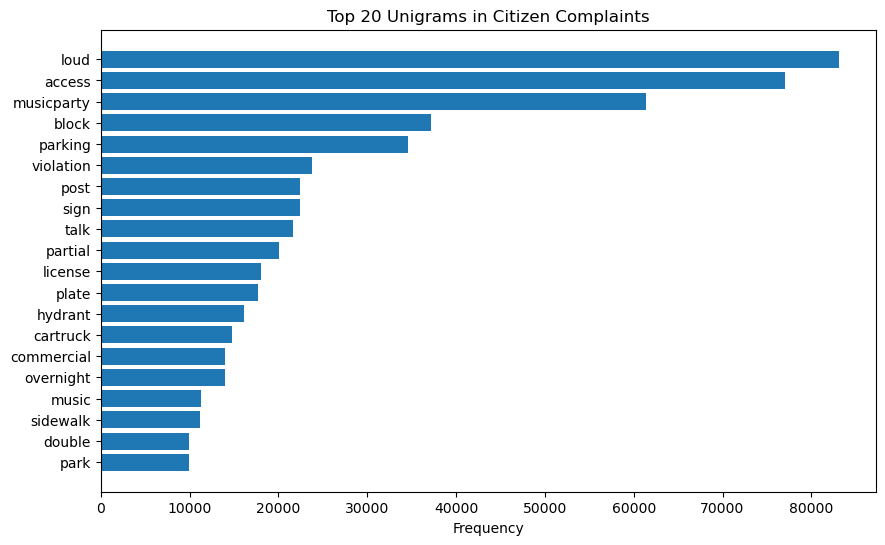

In [13]:
##Plot
plt.figure(figsize=(10,6))
plt.barh(unigram_df["Word"], unigram_df["Frequency"])
plt.gca().invert_yaxis()
plt.title("Top 20 Unigrams in Citizen Complaints")
plt.xlabel("Frequency")
plt.show()

In [15]:
##Bigram Frequency (Two Word Phrases)
top_bigrams = get_top_ngrams(text_data, (2,2), 20)

bigram_df = pd.DataFrame(top_bigrams, columns=["Bigram","Frequency"])

bigram_df


,Bigram,Frequency
0,loud musicparty,61430
1,post parking,22440
2,parking sign,22440
3,sign violation,22440
4,loud talk,21584
5,partial access,20068
6,license plate,17718
7,block hydrant,16081
8,commercial overnight,12189
9,overnight parking,12189


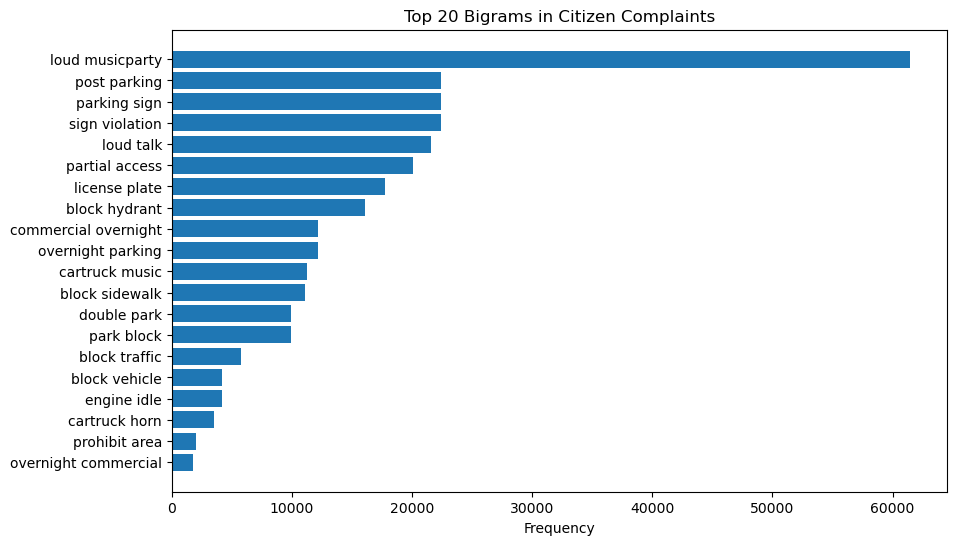

In [16]:
##Plot
plt.figure(figsize=(10,6))
plt.barh(bigram_df["Bigram"], bigram_df["Frequency"])
plt.gca().invert_yaxis()
plt.title("Top 20 Bigrams in Citizen Complaints")
plt.xlabel("Frequency")
plt.show()

In [17]:
##Trigram Frequency (Three Word Phrases)
top_trigrams = get_top_ngrams(text_data, (3,3), 20)

trigram_df = pd.DataFrame(top_trigrams, columns=["Trigram","Frequency"])

trigram_df


,Trigram,Frequency
0,post parking sign,22440
1,parking sign violation,22440
2,commercial overnight parking,12189
3,double park block,9942
4,park block traffic,5731
5,park block vehicle,4211
6,overnight commercial storage,1757
7,unauthorized bus layover,1367
8,truck route violation,1014
9,chronic stoplight violation,280


Text(0.5, 0, 'Frequency')

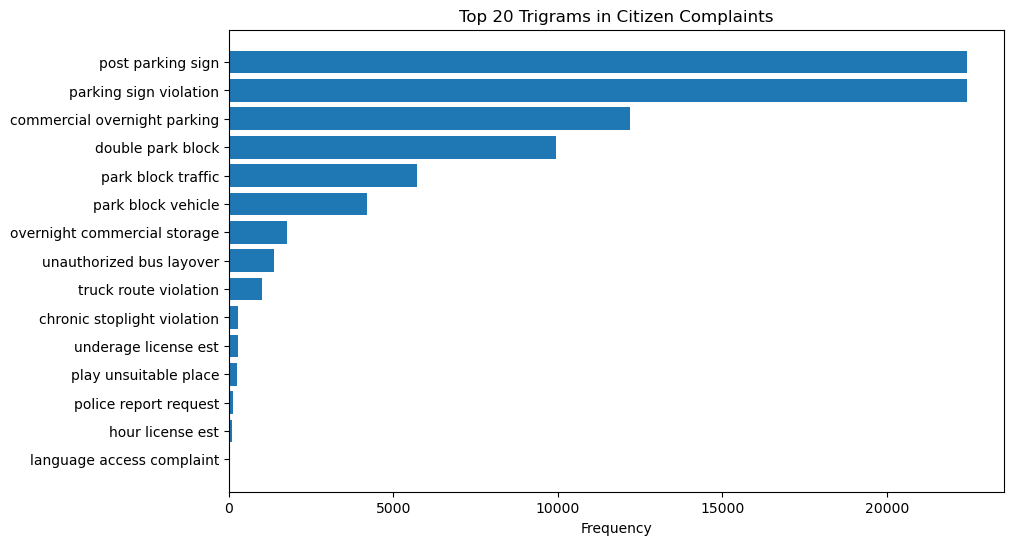

In [18]:
##Plot
plt.figure(figsize=(10,6))
plt.barh(trigram_df["Trigram"], trigram_df["Frequency"])
plt.gca().invert_yaxis()
plt.title("Top 20 Trigrams in Citizen Complaints")
plt.xlabel("Frequency")

In [19]:
##Save Results
unigram_df.to_csv("unigram_frequency.csv", index=False)
bigram_df.to_csv("bigram_frequency.csv", index=False)
trigram_df.to_csv("trigram_frequency.csv", index=False)

In [22]:
"""
N-gram Frequency Analysis

N-grams are groups of words used to find the most common words and phrases in citizen complaints.

Unigrams show the most common single words in complaints.
Bigrams show common two-word phrases like illegal parking or loud music.
Trigrams show three-word phrases that give more context, such as loud music party.

This analysis helps understand the main problems reported by citizens, so government departments can identify important issues and respond faster.
"""

'\nN-gram Frequency Analysis\n\nN-grams are groups of words used to find the most common words and phrases in citizen complaints.\n\nUnigrams show the most common single words in complaints.\nBigrams show common two-word phrases like illegal parking or loud music.\nTrigrams show three-word phrases that give more context, such as loud music party.\n\nThis analysis helps understand the main problems reported by citizens, so government departments can identify important issues and respond faster.\n'